In [1]:
# setup/repo
import numpy as np
import pandas as pd
import os
import json
import pickle

!rm -rf PGST
!git clone --quiet https://github.com/mickdeines/PGST/
os.chdir("PGST")

In [2]:
# -----------------------------
# Inputs
# -----------------------------
HOURLY_TEMPS_FILE = "ERA5 Hourly Temperatures 2015-2026.csv"
HOURLY_TIME_COL   = "time_pacific"
HOURLY_TEMP_COL   = "t2m_F"

REG_WINDOWS_FILE = "Propane Regression Delivery Windows 2023-2025.csv"
REG_PARAMS_FILE   = "regression_params.json"

MMBTU_PER_GAL     = 0.09142
BTU_PER_GALLON    = MMBTU_PER_GAL * 1e6

BALANCE_POINT_F   = 60
DESIGN_MIN_F      = 20
ANALYSIS_YEARS = [2023, 2024, 2025]
ANALYSIS_YEAR  = 2024   # keep for REopt export & plot labels

# Heating baseline (controls / fighting thermostats)
HEAT_BASELINE_ENABLED = True
HEAT_BASELINE_DC      = 0.25   # +30% duty cycle floor

# Allocate baseline only to selected heating units (base case: boiler only)
HEAT_BASELINE_UNITS = {"unit_1"}   # {"unit_1","unit_3"} if we want to include CFS later

In [3]:
# Boiler override (facilities hysteresis)
BOILER_SHUTOFF_TEMP_F    = 60   # outdoor temp above which thermostat fighting (AC vs. boiler) causes shutoff
BOILER_RESTART_TEMP_F    = 54   # outdoor temp below which facilities restores it
BOILER_SHUTOFF_DELAY_HRS = 12    # hours above threshold before facilities acts
BOILER_RESTART_DELAY_HRS = 12    # hours below threshold before he restores it

In [4]:
HEATING_EQUIPMENT = {
    "unit_1": {
        "name": "Boiler",
        "rated_input_btu_hr": 378000,
        "efficiency": 314000/378000,
        "occupied_days": [0,1,2,3,4,5,6],
        "occupied_start_hr": 7,
        "occupied_end_hr": 18,
        "setback_temp_f": 60, # because setback_temp = BALANCE_POINT_F, scheduling currently doesn't do anything, but nice to keep the capability
    },
    "unit_2": {
        "name": "Gym Furnace",
        "rated_input_btu_hr": 400000,
        "efficiency": 0.81,
        "occupied_days": [0,1,2,3,4,5,6],
        "occupied_start_hr": 15,
        "occupied_end_hr": 21,
        "setback_temp_f": 0,
        "balance_point_f": 70,
        "gym_recovery_hours": 3,
        "scale_factor": 1,  # scale_factor = 1 --> no effect

    },
    "unit_3": {
        "name": "CFS Furnace 1, 2, & 3",
        "rated_input_btu_hr": 74000*3,
        "efficiency": 0.80,
        "occupied_days": [0,1,2,3,4,5,6],
        "occupied_start_hr": 7,
        "occupied_end_hr": 18,
        "setback_temp_f": 60,
    },
}

In [5]:
NON_HEATING_EQUIPMENT = {
    "ecc_dhw_heater": {
        "name": "ECC Domestic Hot Water Heater",
        "rated_input_btu_hr": 75000,
       "occupied_days": [0,1,2,3,4],
        "windows": [(8,9), (10,11), (12,13), (14,15), (16,17)],
        "utilization": 1.0,
    },
    "ecc_stove": {
        "name": "ECC Stoves",
        "rated_input_btu_hr": 288000+120000,
        "occupied_days": [0,1,2,3,4],
        "occupied_start_hr": 8,
        "occupied_end_hr": 9,
        "occupied_start_hr_2": 11,
        "occupied_end_hr_2": 13,
        "utilization": 0.60,
    },
    "admin_stove": {
        "name": "Admin Kitchen Stove",
        "rated_input_btu_hr": 60000,
        "occupied_days": [0,1,2,3,4],
        "occupied_start_hr": 11,
        "occupied_end_hr": 12,
        "utilization": 0.20,
    },
    "elder_stove": {
        "name": "Elder Center Stove",
        "rated_input_btu_hr": 302000,
        "occupied_days": [0,1,2,3,4,5,6],
        "occupied_start_hr": 7,
        "occupied_end_hr": 9,
        "occupied_start_hr_2": 11,
       "occupied_end_hr_2": 13,
        "utilization": 0.60,
    },
}

In [6]:
# -----------------------------
# Helper functions
# -----------------------------
def annual_gallons_from_windows(reg_windows_file, year):
    w = pd.read_csv(reg_windows_file)
    w["start_date"] = pd.to_datetime(w["start_date"], errors="coerce")
    w["end_date"]   = pd.to_datetime(w["end_date"], errors="coerce")
    w["gallons"]    = pd.to_numeric(w["gallons"], errors="coerce")
    w["days"]       = pd.to_numeric(w["days"], errors="coerce")
    w = w.dropna(subset=["start_date","end_date","gallons","days"])
    w = w[w["days"] > 0].copy()

    year_start = pd.Timestamp(f"{year}-01-01")
    year_end   = pd.Timestamp(f"{year+1}-01-01")

    overlap_start = w["start_date"].where(w["start_date"] > year_start, year_start)
    overlap_end   = w["end_date"].where(w["end_date"] < year_end, year_end)

    overlap_days = (overlap_end - overlap_start).dt.days.clip(lower=0)

    allocated = w["gallons"] * (overlap_days / w["days"])
    return float(allocated.sum())

def weather_dc_for_unit(index, temp_f, is_occupied, setback_temp_f,
                        dc_occ_shared=None,
                        balance_point=BALANCE_POINT_F,
                        design_min=DESIGN_MIN_F):
    """
    Weather-driven duty cycle:
      - during occupied hours: use balance_point (default BALANCE_POINT_F)
      - during unoccupied hours: use setback_temp_f (or 0 if <= design_min)

    If dc_occ_shared is provided, it is used for the occupied-hours DC.
    """
    if dc_occ_shared is None:
        dc_occupied = compute_duty_cycle(temp_f, balance_point=balance_point, design_min=design_min)
    else:
        dc_occupied = dc_occ_shared

    if setback_temp_f <= design_min:
        dc_setback = pd.Series(0.0, index=index)
    else:
        dc_setback = compute_duty_cycle(temp_f, balance_point=setback_temp_f, design_min=design_min)

    return dc_occupied.where(is_occupied, dc_setback)

def compute_duty_cycle(temps_f, balance_point=BALANCE_POINT_F, design_min=DESIGN_MIN_F):
    """
    0% at or above balance_point (no heating needed)
    100% at or below design_min (full rated load)
    Linear between
    """
    dc = (balance_point - temps_f) / (balance_point - design_min)
    return dc.clip(lower=0.0, upper=1.0)

def build_occupied_mask(index, params, dow=None, hour=None):
    """
    Returns a boolean Series indexed like `index` indicating occupied hours.

    Supports either:
      - params["windows"] = [(start_hr, end_hr),...]
      - legacy keys: occupied_start_hr/occupied_end_hr and optional _2
    Requires:
      - params["occupied_days"] as list of dayofweek ints (0=Mon... 6=Sun)

    Pass `dow` and `hour` (precomputed from index) to avoid repeated index access.
    """
    if dow is None:
        dow = index.dayofweek
    if hour is None:
        hour = index.hour

    # Collect windows
    if "windows" in params and params["windows"] is not None:
        wins = list(params["windows"])
    else:
        wins = []
        if "occupied_start_hr" in params and "occupied_end_hr" in params:
            wins.append((params["occupied_start_hr"], params["occupied_end_hr"]))
        if "occupied_start_hr_2" in params and "occupied_end_hr_2" in params:
            wins.append((params["occupied_start_hr_2"], params["occupied_end_hr_2"]))

    is_occupied = pd.Series(False, index=index)
    if not wins:
        return is_occupied

    day_mask = pd.Series(dow, index=index).isin(params["occupied_days"])

    for s, e in wins:
        s = int(s); e = int(e)
        is_occupied |= (day_mask & (hour >= s) & (hour < e))

    return is_occupied

In [7]:
# -----------------------------
# Load hourly temperatures (2024)
# -----------------------------
temps = pd.read_csv(HOURLY_TEMPS_FILE)

# parse as UTC then convert to America/Los_Angeles.
temps[HOURLY_TIME_COL] = pd.to_datetime(temps[HOURLY_TIME_COL], errors="coerce", utc=True)
temps = temps.dropna(subset=[HOURLY_TIME_COL]).set_index(HOURLY_TIME_COL)
temps.index = temps.index.tz_convert("America/Los_Angeles")

# Build df for analysis year
df = pd.DataFrame(index=temps.index)
df["temp_f"] = pd.to_numeric(temps[HOURLY_TEMP_COL], errors="coerce")
df = df.dropna(subset=["temp_f"])

df = df[df.index.year.isin(ANALYSIS_YEARS)].sort_index()

IDX_DOW  = df.index.dayofweek   # Int64Index-like
IDX_HOUR = df.index.hour        # Int64Index-like

print(f"Hours in CY{ANALYSIS_YEAR}: {len(df):,}")
print(f"Date range : {df.index.min()} → {df.index.max()}")
print(f"Temp range : {df['temp_f'].min():.1f}°F – {df['temp_f'].max():.1f}°F")

Hours in CY2024: 26,304
Date range : 2023-01-01 00:00:00-08:00 → 2025-12-31 23:00:00-08:00
Temp range : 16.8°F – 81.4°F


In [8]:
# -----------------------------
# Targets from regression baseline
# -----------------------------
reg_params = json.load(open(REG_PARAMS_FILE))

In [9]:
# Stateful boiler override mask — simulates facilities guy cycling the boiler
# when thermostat fighting causes overheating at mild outdoor temps.
# Both weather-driven and baseline (fighting) load go to zero when boiler is off.
boiler_allowed = pd.Series(1.0, index=df.index)
boiler_on = True
hrs_too_hot = 0
hrs_too_cold = 0
for i in range(len(df)):
    temp = df["temp_f"].iloc[i]
    if boiler_on:
        if temp > BOILER_SHUTOFF_TEMP_F:
            hrs_too_hot += 1
            hrs_too_cold = 0
        else:
            hrs_too_hot = 0
        if hrs_too_hot >= BOILER_SHUTOFF_DELAY_HRS:
            boiler_on = False
            hrs_too_hot = 0
    else:
        boiler_allowed.iloc[i] = 0.0
        if temp < BOILER_RESTART_TEMP_F:
            hrs_too_cold += 1
            hrs_too_hot = 0
        else:
            hrs_too_cold = 0
        if hrs_too_cold >= BOILER_RESTART_DELAY_HRS:
            boiler_on = True
            hrs_too_cold = 0

In [10]:
# -----------------------------
# Build unscaled heating loads
# -----------------------------
dc_occ_shared = compute_duty_cycle(df["temp_f"], balance_point=BALANCE_POINT_F, design_min=DESIGN_MIN_F) # precompute
heating_summary = []

for uid, params in HEATING_EQUIPMENT.items():

    is_occupied = build_occupied_mask(df.index, params, dow=IDX_DOW, hour=IDX_HOUR)

    dc_weather = weather_dc_for_unit(index=df.index, temp_f=df["temp_f"], is_occupied=is_occupied, setback_temp_f=params["setback_temp_f"], dc_occ_shared=dc_occ_shared)

    # ── Gym furnace: cold-soak recovery ──────────────────────
    if uid == "unit_2":
      # Identify first hour of each occupied block
      occupied_starts = is_occupied & ~is_occupied.shift(1, fill_value=False)

      # Build recovery mask: first GYM_RECOVERY_HOURS of each occupied block
      recovery_mask = pd.Series(False, index=df.index)
      for start_time in df.index[occupied_starts]:
        end_time = start_time + pd.Timedelta(hours=params['gym_recovery_hours'] - 1)
        recovery_mask.loc[start_time:end_time] = True
      recovery_mask = recovery_mask & is_occupied  # don't bleed outside occupied window

      # Recovery DC: temperature-dependent, using setpoint as balance point
      dc_recovery = compute_duty_cycle(
        df["temp_f"],
        balance_point=params['balance_point_f'],
        design_min=DESIGN_MIN_F
      )

      # During recovery hours: take max of recovery and steady-state
      # (recovery never reduces below what weather alone predicts)
      dc_weather = dc_weather.where(~recovery_mask, np.maximum(dc_recovery, dc_weather))

    # Start with weather, then apply floor (if enabled for this unit)
    dc = dc_weather.copy()

    if HEAT_BASELINE_ENABLED and (uid in HEAT_BASELINE_UNITS):
      dc = np.maximum(dc, HEAT_BASELINE_DC)

    # Incremental duty cycle attributable to baseline heating (controls)
    dc_baseline_inc = (dc - dc_weather).clip(lower=0.0)

    # Apply facilities override: zeros both weather and fighting load when boiler is off
    if uid == "unit_1":
        dc_weather      = dc_weather      * boiler_allowed
        dc_baseline_inc = dc_baseline_inc * boiler_allowed

    # Apply per-unit scale factor (defaults to 1.0). Gym is set to 0.10 above.
    scale = float(params.get("scale_factor", 1.0))

    hourly_btu_weather = params["rated_input_btu_hr"] * dc_weather * scale
    hourly_btu_baseinc = params["rated_input_btu_hr"] * dc_baseline_inc * scale
    hourly_btu_input   = hourly_btu_weather + hourly_btu_baseinc

    df[f"heat_btu_in_{uid}"] = hourly_btu_input
    df[f"heat_btu_baseinc_{uid}"] = params["rated_input_btu_hr"] * dc_baseline_inc * scale

    heating_summary.append({
        "unit_id": uid,
        "name": params["name"],
        "scale_factor": scale,
        "setback_temp_f": params["setback_temp_f"],
        "occupied_hrs/yr": int(is_occupied.sum()),
        "annual_gallons_weather_unscaled": hourly_btu_weather.sum() / BTU_PER_GALLON,
        "annual_gallons_baseline_unscaled": hourly_btu_baseinc.sum() / BTU_PER_GALLON,
        "annual_gallons_unscaled": hourly_btu_input.sum() / BTU_PER_GALLON,
    })

df_heat_sum = pd.DataFrame(heating_summary).set_index("unit_id")
UNSCALED_HEAT_GAL_WEATHER  = float(df_heat_sum["annual_gallons_weather_unscaled"].sum())
UNSCALED_HEAT_GAL_BASELINE = float(df_heat_sum["annual_gallons_baseline_unscaled"].sum())
UNSCALED_HEAT_GAL          = float(df_heat_sum["annual_gallons_unscaled"].sum())

In [11]:
# -----------------------------
# Build unscaled non-heating loads (with utilization)
# -----------------------------
nonheat_summary = []

for uid, params in NON_HEATING_EQUIPMENT.items():

    is_occupied = build_occupied_mask(df.index, params, dow=IDX_DOW, hour=IDX_HOUR)

    util = float(params.get("utilization", 1.0))

    hourly_btu_input = pd.Series(
        np.where(is_occupied, params["rated_input_btu_hr"] * util, 0.0),
        index=df.index
    )

    df[f"nonheat_btu_in_{uid}"] = hourly_btu_input

    nonheat_summary.append({
        "unit_id": uid,
        "name": params["name"],
        "occupied_hrs/yr": int(is_occupied.sum()),
        "utilization": util,
        "annual_gallons_unscaled": hourly_btu_input.sum() / BTU_PER_GALLON,
    })

df_nonheat_sum = pd.DataFrame(nonheat_summary).set_index("unit_id")
UNSCALED_NONHEAT_GAL = float(df_nonheat_sum["annual_gallons_unscaled"].sum())

print("\n── Non-Heating Equipment (Unscaled) ─────────────────")
print(df_nonheat_sum.to_string())
print(f"\nUnscaled total non-heating: {UNSCALED_NONHEAT_GAL:,.0f} gallons")


── Non-Heating Equipment (Unscaled) ─────────────────
                                         name  occupied_hrs/yr  utilization  annual_gallons_unscaled
unit_id                                                                                             
ecc_dhw_heater  ECC Domestic Hot Water Heater             3915          1.0              3211.824546
ecc_stove                          ECC Stoves             2349          0.6              6290.037191
admin_stove               Admin Kitchen Stove              783          0.2               102.778385
elder_stove                Elder Center Stove             4384          0.6              8689.354627

Unscaled total non-heating: 18,294 gallons


In [12]:
# ── Per-year scaling ────────────────────────────────────────────────────────
_baseinc_cols = [f"heat_btu_baseinc_{uid}" for uid in HEATING_EQUIPMENT
                 if f"heat_btu_baseinc_{uid}" in df.columns]
_heat_cols    = [f"heat_btu_in_{uid}"      for uid in HEATING_EQUIPMENT
                 if f"heat_btu_in_{uid}"      in df.columns]
_nheat_cols   = [f"nonheat_btu_in_{uid}"   for uid in NON_HEATING_EQUIPMENT
                 if f"nonheat_btu_in_{uid}"   in df.columns]

year_scales = {}

for _y in ANALYSIS_YEARS:
    _mask  = df.index.year == _y
    _days  = df[_mask].index.normalize().nunique()

    _reg_baseline = reg_params["baseline_gpd"] * _days
    _target_total = annual_gallons_from_windows(REG_WINDOWS_FILE, _y)

    _unscaled_heat_bl = df.loc[_mask, _baseinc_cols].sum().sum() / BTU_PER_GALLON
    _unscaled_heat    = df.loc[_mask, _heat_cols].sum().sum()    / BTU_PER_GALLON
    _unscaled_nonheat = df.loc[_mask, _nheat_cols].sum().sum()   / BTU_PER_GALLON

    _target_nonheat = max(0.0, _reg_baseline - _unscaled_heat_bl)
    _target_heat    = _target_total - _target_nonheat
    if _target_heat < 0:
        raise ValueError(f"CY{_y}: TARGET_HEAT_GAL_ANNUAL is negative.")

    _hs = (_target_heat    / _unscaled_heat)    if _unscaled_heat    > 0 else 0.0
    _ns = (_target_nonheat / _unscaled_nonheat) if _unscaled_nonheat > 0 else 0.0
    year_scales[_y] = {"heat": _hs, "nonheat": _ns}

    print(f"\n══ CY{_y} ════════════════════════════════════════════")
    print(f"  Total target       : {_target_total:>10,.0f} gal")
    print(f"  Regression baseline: {_reg_baseline:>10,.0f} gal  ({reg_params['baseline_gpd']:.2f} gal/day)")
    print(f"  Baseline-heat model: {_unscaled_heat_bl:>10,.0f} gal")
    print(f"  Non-heat target    : {_target_nonheat:>10,.0f} gal")
    print(f"  Heat target        : {_target_heat:>10,.0f} gal")
    print(f"  Heat scale         : {_hs:.4f}    Non-heat scale: {_ns:.4f}")

    for _col in _heat_cols:
        df.loc[_mask, _col] *= _hs
    for _col in _nheat_cols:
        df.loc[_mask, _col] *= _ns

    # Cap and redistribute within this year
    for _uid, _p in HEATING_EQUIPMENT.items():
        _col = f"heat_btu_in_{_uid}"
        if _col not in df.columns:
            continue
        _cap      = _p["rated_input_btu_hr"]
        _excess   = (df.loc[_mask, _col] - _cap).clip(lower=0).sum()
        df.loc[_mask, _col] = df.loc[_mask, _col].clip(upper=_cap)
        _headroom = (_cap - df.loc[_mask, _col]).clip(lower=0)
        _total_hw = _headroom.sum()
        if _total_hw > 0:
            df.loc[_mask, _col] += _headroom * (_excess / _total_hw)
        tag = f"redistributed {_excess/BTU_PER_GALLON:.1f} gal excess" if _excess > 0 else "no excess (clean)"
        print(f"  {_p['name']}: {tag}")

    _H = df.loc[_mask, _heat_cols].sum().sum()  / BTU_PER_GALLON
    _N = df.loc[_mask, _nheat_cols].sum().sum() / BTU_PER_GALLON
    print(f"  ── Heating {_H:,.0f} | Non-heat {_N:,.0f} | Total {_H+_N:,.0f} gal")

# Aggregate effective scales — keeps the pie-chart section below working unchanged
heat_scale    = df[_heat_cols].sum().sum()  / BTU_PER_GALLON / df_heat_sum["annual_gallons_unscaled"].sum()
nonheat_scale = df[_nheat_cols].sum().sum() / BTU_PER_GALLON / df_nonheat_sum["annual_gallons_unscaled"].sum()


══ CY2023 ════════════════════════════════════════════
  Total target       :     25,345 gal
  Regression baseline:      6,819 gal  (18.68 gal/day)
  Baseline-heat model:        783 gal
  Non-heat target    :      6,036 gal
  Heat target        :     19,310 gal
  Heat scale         : 1.2752    Non-heat scale: 0.9922
  Boiler: redistributed 0.1 gal excess
  Gym Furnace: no excess (clean)
  CFS Furnace 1, 2, & 3: redistributed 0.1 gal excess
  ── Heating 19,310 | Non-heat 6,036 | Total 25,345 gal

══ CY2024 ════════════════════════════════════════════
  Total target       :     24,040 gal
  Regression baseline:      6,838 gal  (18.68 gal/day)
  Baseline-heat model:        844 gal
  Non-heat target    :      5,994 gal
  Heat target        :     18,047 gal
  Heat scale         : 1.1828    Non-heat scale: 0.9801
  Boiler: redistributed 28.1 gal excess
  Gym Furnace: redistributed 5.6 gal excess
  CFS Furnace 1, 2, & 3: redistributed 16.5 gal excess
  ── Heating 18,047 | Non-heat 5,994 | To

In [13]:
# ── Annual propane summary ────────────────────────────────────────────────────

print(f"{'Year':<6} {'Heating (gal)':>14} {'Non-Heating (gal)':>18} {'Total (gal)':>12}")
print("─" * 54)

for yr in ANALYSIS_YEARS:
    mask = df.index.year == yr
    heat    = df.loc[mask, _heat_cols].sum().sum()  / BTU_PER_GALLON
    nonheat = df.loc[mask, _nheat_cols].sum().sum() / BTU_PER_GALLON
    print(f"{yr:<6} {heat:>14,.1f} {nonheat:>18,.1f} {heat+nonheat:>12,.1f}")

Year    Heating (gal)  Non-Heating (gal)  Total (gal)
──────────────────────────────────────────────────────
2023         19,309.5            6,035.6     25,345.1
2024         18,046.8            5,993.6     24,040.5
2025         18,074.1            6,056.6     24,130.7


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPORT BUNDLE (for a separate "REopt exports" notebook)
#
# Run this ONCE after df is fully built/scaled (and year_scales exists).
# It writes a single pickle bundle + a small JSON manifest.
#
# The new notebook can load this bundle and generate all REopt CSVs without
# re-running the full pipeline.
#
# Exports:
#   - df_reopt_src: minimal hourly data needed (temp_f + device btu columns)
#   - HEATING_EQUIPMENT, NON_HEATING_EQUIPMENT
#   - ANALYSIS_YEAR, ANALYSIS_YEARS, DESIGN_MIN_F, BTU_PER_GALLON
#   - year_scales (for fixed-controls / weather-only exports)
#   - tz name
# ─────────────────────────────────────────────────────────────────────────────
EXPORT_DIR  = "exports_for_reopt"
EXPORT_BASE = f"reopt_bundle_CY{ANALYSIS_YEAR}"
os.makedirs(EXPORT_DIR, exist_ok=True)

# --- minimal columns the REopt-export notebook will need ---
device_cols = [c for c in df.columns if c.startswith("heat_btu_in_") or c.startswith("nonheat_btu_in_")]
need_cols = ["temp_f"] + device_cols

missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

df_reopt_src = df[need_cols].copy()

# Ensure tz-aware index survives
if df_reopt_src.index.tz is None:
    raise ValueError("df index is not timezone-aware; REopt bundle expects tz-aware timestamps.")
tz_name = str(df_reopt_src.index.tz)

# Optional sanity: make sure year_scales has the analysis year
if int(ANALYSIS_YEAR) not in {int(k) for k in year_scales.keys()}:
    raise ValueError(f"year_scales missing ANALYSIS_YEAR={ANALYSIS_YEAR}. Keys: {list(year_scales.keys())}")

bundle = {
    "df": df_reopt_src,
    "HEATING_EQUIPMENT": HEATING_EQUIPMENT,
    "NON_HEATING_EQUIPMENT": NON_HEATING_EQUIPMENT,
    "ANALYSIS_YEAR": int(ANALYSIS_YEAR),
    "ANALYSIS_YEARS": [int(y) for y in ANALYSIS_YEARS],
    "DESIGN_MIN_F": float(DESIGN_MIN_F),
    "BTU_PER_GALLON": float(BTU_PER_GALLON),
    "year_scales": {int(y): {"heat": float(v["heat"]), "nonheat": float(v["nonheat"])} for y, v in year_scales.items()},
    "tz": tz_name,
}

pkl_path = os.path.join(EXPORT_DIR, f"{EXPORT_BASE}.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

manifest = {
    "bundle": os.path.basename(pkl_path),
    "tz": tz_name,
    "analysis_year": int(ANALYSIS_YEAR),
    "analysis_years": [int(y) for y in ANALYSIS_YEARS],
    "n_rows": int(len(df_reopt_src)),
    "n_cols": int(df_reopt_src.shape[1]),
    "includes_temp_f": True,
    "n_device_cols": int(len(device_cols)),
    "device_cols_preview": device_cols[:12],
    "notes": "Load this bundle in a clean notebook to generate REopt CSV exports without re-running the full model.",
}

json_path = os.path.join(EXPORT_DIR, f"{EXPORT_BASE}_manifest.json")
with open(json_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("Wrote REopt bundle   :", pkl_path)
print("Wrote REopt manifest :", json_path)
print("df_reopt_src shape   :", df_reopt_src.shape)
print("tz                   :", tz_name)

Wrote REopt bundle   : exports_for_reopt/reopt_bundle_CY2024.pkl
Wrote REopt manifest : exports_for_reopt/reopt_bundle_CY2024_manifest.json
df_reopt_src shape   : (26304, 8)
tz                   : America/Los_Angeles


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPORT CELL (run once, right before the final drop-in plotting cell)
# Writes a single portable bundle you can load in another notebook to run the
# interactive viewer without re-running the full pipeline.
# Exports: df (needed columns), HEATING_EQUIPMENT, NON_HEATING_EQUIPMENT,
#          ANALYSIS_YEAR, ANALYSIS_YEARS, plus tz info.
# ─────────────────────────────────────────────────────────────────────────────
EXPORT_DIR  = "exports_for_viewer"
EXPORT_BASE = f"viewer_bundle_CY{ANALYSIS_YEAR}"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1) Keep only what the viewer needs (device columns + index)
device_cols = [c for c in df.columns if c.startswith("heat_btu_in_") or c.startswith("nonheat_btu_in_")]
df_view = df[device_cols].copy()

# Ensure tz-aware index is preserved cleanly
if df_view.index.tz is None:
    raise ValueError("df index is not timezone-aware; viewer expects tz-aware timestamps.")
tz_name = str(df_view.index.tz)

# 2) Save df in a robust format (pickle preserves tz + dtypes reliably)
pkl_path = os.path.join(EXPORT_DIR, f"{EXPORT_BASE}.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(
        {
            "df": df_view,
            "HEATING_EQUIPMENT": HEATING_EQUIPMENT,
            "NON_HEATING_EQUIPMENT": NON_HEATING_EQUIPMENT,
            "ANALYSIS_YEAR": ANALYSIS_YEAR,
            "ANALYSIS_YEARS": ANALYSIS_YEARS,
            "tz": tz_name,
        },
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

# 3) Also write a small JSON manifest (human-readable)
manifest = {
    "bundle": os.path.basename(pkl_path),
    "tz": tz_name,
    "analysis_year": int(ANALYSIS_YEAR),
    "analysis_years": [int(y) for y in ANALYSIS_YEARS],
    "n_rows": int(len(df_view)),
    "n_device_cols": int(len(device_cols)),
    "device_cols_preview": device_cols[:10],
}
json_path = os.path.join(EXPORT_DIR, f"{EXPORT_BASE}_manifest.json")
with open(json_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("Wrote bundle:", pkl_path)
print("Wrote manifest:", json_path)
print("df_view shape:", df_view.shape)
print("tz:", tz_name)

Wrote bundle: exports_for_viewer/viewer_bundle_CY2024.pkl
Wrote manifest: exports_for_viewer/viewer_bundle_CY2024_manifest.json
df_view shape: (26304, 7)
tz: America/Los_Angeles


In [16]:
# =============================================================================
# A) MODIFIED PIE VIEWER BUNDLE EXPORT CELL (main pipeline notebook)
# -----------------------------------------------------------------------------
# Run once after you’ve built/scaled df and computed year_scales.
# Writes a portable bundle you can load elsewhere to render the interactive
# pie charts without re-running the full pipeline.
#
# Adds: boiler_fixed_controls_annual_gal (by year)
# Definition: weather-only boiler duty cycle (no baseline floor, no hysteresis
# mask), scaled by year_scales[year]["heat"], capped+redistributed at rated input.
# =============================================================================

import os, pickle, json
import numpy as np
import pandas as pd

EXPORT_DIR  = "exports_for_viewer"
EXPORT_BASE = f"pie_bundle_CY{ANALYSIS_YEAR}"
os.makedirs(EXPORT_DIR, exist_ok=True)

# --- build device metadata (stable mapping) ---
device_meta = (
    pd.DataFrame(
        [{"unit_id": uid, "device": p["name"], "category": "heating"} for uid, p in HEATING_EQUIPMENT.items()] +
        [{"unit_id": uid, "device": p["name"], "category": "nonheating"} for uid, p in NON_HEATING_EQUIPMENT.items()]
    ).drop_duplicates(subset=["unit_id"], keep="first").reset_index(drop=True)
)

# --- compute per-device annual gallons for each year directly from df (already scaled) ---
rows = []
for y in ANALYSIS_YEARS:
    mask = df.index.year == int(y)

    for uid, p in HEATING_EQUIPMENT.items():
        col = f"heat_btu_in_{uid}"
        if col in df.columns:
            rows.append({
                "year": int(y),
                "unit_id": uid,
                "device": p["name"],
                "category": "heating",
                "annual_gal": float(df.loc[mask, col].sum() / BTU_PER_GALLON),
            })

    for uid, p in NON_HEATING_EQUIPMENT.items():
        col = f"nonheat_btu_in_{uid}"
        if col in df.columns:
            rows.append({
                "year": int(y),
                "unit_id": uid,
                "device": p["name"],
                "category": "nonheating",
                "annual_gal": float(df.loc[mask, col].sum() / BTU_PER_GALLON),
            })

pie_df_all_years = (
    pd.DataFrame(rows)
      .sort_values(["year", "category", "annual_gal"], ascending=[True, True, False])
      .reset_index(drop=True)
)

# --- config used by the pie plotting cell ---
small_devices = {
    "ECC Domestic Hot Water Heater",
    "ECC Stove",
    "Admin Kitchen Stove",
    "Gym Furnace",
}

warm_colors = ["#d62728", "#e65100", "#ff7f0e", "#ff6b6b"]
cool_colors = ["#1f77b4", "#4fc3f7", "#2ca02c", "#66bb6a", "#0097a7"]

# --- helpers for fixed-controls boiler annual gallons ---

def compute_duty_cycle(temps_f, balance_point=60, design_min=20):
    """0% at/above balance_point, 100% at/below design_min, linear between."""
    dc = (balance_point - temps_f) / (balance_point - design_min)
    return pd.Series(dc, index=temps_f.index).clip(lower=0.0, upper=1.0)


def cap_and_redistribute(x, cap):
    """Cap hourly array at cap and redistribute clipped energy into headroom hours."""
    x = np.asarray(x, dtype=float).clip(min=0)
    excess = np.clip(x - cap, 0, None).sum()
    x = np.clip(x, None, cap)
    headroom = np.clip(cap - x, 0, None)
    total_hw = headroom.sum()
    if total_hw > 0 and excess > 0:
        x = x + headroom * (excess / total_hw)
    return x


def _occupied_mask(index, p):
    # legacy single window for boiler (matches your REopt export)
    s, e = int(p["occupied_start_hr"]), int(p["occupied_end_hr"])
    return (
        index.dayofweek.isin(p["occupied_days"]) &
        (index.hour >= s) &
        (index.hour < e)
    )


def boiler_fixed_controls_annual_gal_for_year(df_year, boiler_params, design_min_f, btu_per_gal, heat_scale):
    """Return annual gallons for boiler under fixed-controls definition."""
    is_occ = _occupied_mask(df_year.index, boiler_params)

    dc_occ = compute_duty_cycle(df_year["temp_f"], balance_point=60, design_min=design_min_f)

    setback = float(boiler_params.get("setback_temp_f", 0))
    if setback > float(design_min_f):
        dc_set = compute_duty_cycle(df_year["temp_f"], balance_point=setback, design_min=design_min_f)
    else:
        dc_set = pd.Series(0.0, index=df_year.index)

    dc_weather = dc_occ.where(is_occ, dc_set)

    rated_in = float(boiler_params["rated_input_btu_hr"])
    btu_in = rated_in * dc_weather.values * float(heat_scale)

    # cap+redistribute at rated input
    btu_in = cap_and_redistribute(btu_in, cap=rated_in)

    annual_gal = float(np.sum(btu_in) / float(btu_per_gal))
    return annual_gal


# --- compute fixed-controls boiler annual gallons by year ---
if "temp_f" not in df.columns:
    raise ValueError("pie bundle export needs df['temp_f'] to compute fixed-controls boiler annual gallons.")

boiler_uid = "unit_1"
if boiler_uid not in HEATING_EQUIPMENT:
    raise KeyError("HEATING_EQUIPMENT missing unit_1 (boiler).")

boiler_p = HEATING_EQUIPMENT[boiler_uid]

boiler_fixed_controls_annual_gal = {}
for y in ANALYSIS_YEARS:
    y = int(y)
    dfy = df[df.index.year == y]
    hs = float(year_scales[y]["heat"]) if isinstance(year_scales, dict) and y in year_scales else None
    if hs is None:
        raise ValueError(f"year_scales missing heat scale for {y}.")

    boiler_fixed_controls_annual_gal[y] = boiler_fixed_controls_annual_gal_for_year(
        df_year=dfy,
        boiler_params=boiler_p,
        design_min_f=DESIGN_MIN_F,
        btu_per_gal=BTU_PER_GALLON,
        heat_scale=hs,
    )

# --- write bundle ---
pkl_path = os.path.join(EXPORT_DIR, f"{EXPORT_BASE}.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(
        {
            "pie_df_all_years": pie_df_all_years,
            "device_metadata": device_meta,
            "ANALYSIS_YEAR": int(ANALYSIS_YEAR),
            "ANALYSIS_YEARS": [int(y) for y in ANALYSIS_YEARS],
            "BTU_PER_GALLON": float(BTU_PER_GALLON),
            "small_devices": sorted(list(small_devices)),
            "warm_colors": warm_colors,
            "cool_colors": cool_colors,
            "boiler_fixed_controls_annual_gal": {int(k): float(v) for k, v in boiler_fixed_controls_annual_gal.items()},
            "boiler_unit_id": boiler_uid,
            "fixed_controls_definition": "Weather-only boiler duty cycle (no baseline floor, no hysteresis mask), scaled by year_scales[year]['heat'], capped+redistributed at rated input.",
        },
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

manifest = {
    "bundle": os.path.basename(pkl_path),
    "analysis_year": int(ANALYSIS_YEAR),
    "analysis_years": [int(y) for y in ANALYSIS_YEARS],
    "n_rows": int(len(pie_df_all_years)),
    "cols": list(pie_df_all_years.columns),
    "small_devices": sorted(list(small_devices)),
    "includes_boiler_fixed_controls": True,
    "boiler_unit_id": boiler_uid,
}
json_path = os.path.join(EXPORT_DIR, f"{EXPORT_BASE}_manifest.json")
with open(json_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("Wrote pie bundle:", pkl_path)
print("Wrote manifest :", json_path)
print("pie_df_all_years shape:", pie_df_all_years.shape)
print("boiler_fixed_controls_annual_gal:", boiler_fixed_controls_annual_gal)

Wrote pie bundle: exports_for_viewer/pie_bundle_CY2024.pkl
Wrote manifest : exports_for_viewer/pie_bundle_CY2024_manifest.json
pie_df_all_years shape: (21, 5)
boiler_fixed_controls_annual_gal: {2023: 10011.95686743564, 2024: 9290.50865367103, 2025: 9351.18872378379}


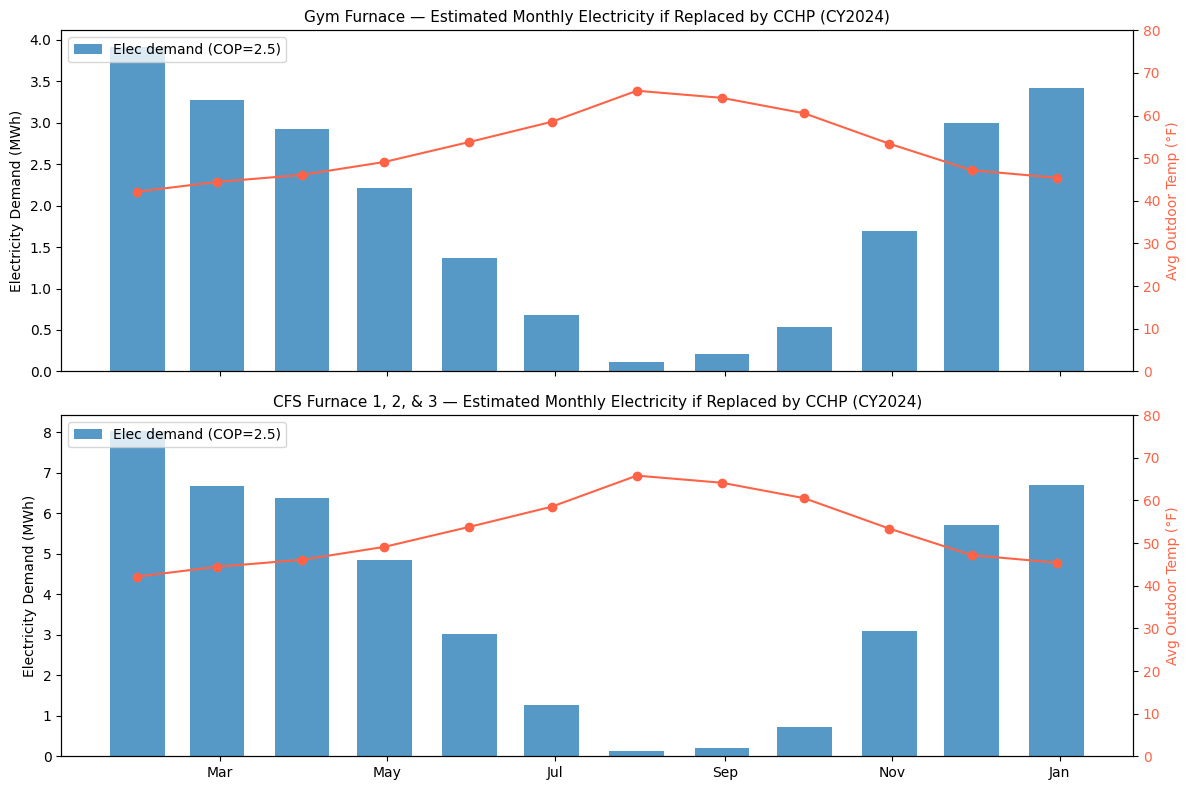

Saved: furnace_hp_monthly_profiles.png

  FURNACE → CCHP ELECTRIFICATION SUMMARY  (CY2024)
  COP assumptions: Low=2.0  Mid=2.5  High=3.5

  Gym Furnace
    Propane input (modeled)  :    2,689 gal/yr
    Thermal output           :    199.1 MMBtu/yr
    Est. electricity (COP 2.0) :     29.2 MWh/yr  [conservative]
    Est. electricity (COP 2.5) :     23.3 MWh/yr  [central estimate]
    Est. electricity (COP 3.5) :     16.7 MWh/yr  [optimistic]
    Peak hourly draw (COP 2.5):     38.0 kW

  CFS Furnace 1, 2, & 3
    Propane input (modeled)  :    5,456 gal/yr
    Thermal output           :    399.1 MMBtu/yr
    Est. electricity (COP 2.0) :     58.5 MWh/yr  [conservative]
    Est. electricity (COP 2.5) :     46.8 MWh/yr  [central estimate]
    Est. electricity (COP 3.5) :     33.4 MWh/yr  [optimistic]
    Peak hourly draw (COP 2.5):     20.8 kW

  ── COMBINED TOTALS ──────────────────────────────────
    Annual electricity (COP 2.0):     87.7 MWh/yr
    Annual electricity (COP 2.5):     70.1

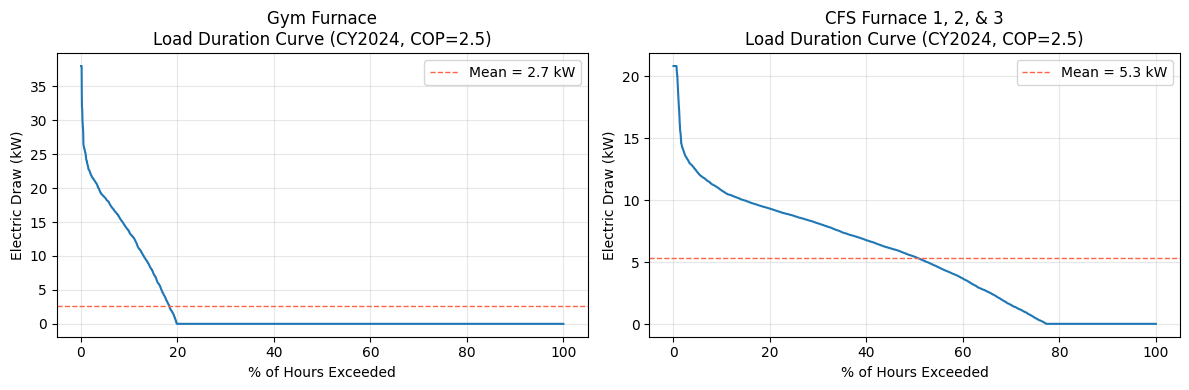

Saved: furnace_hp_load_duration.png


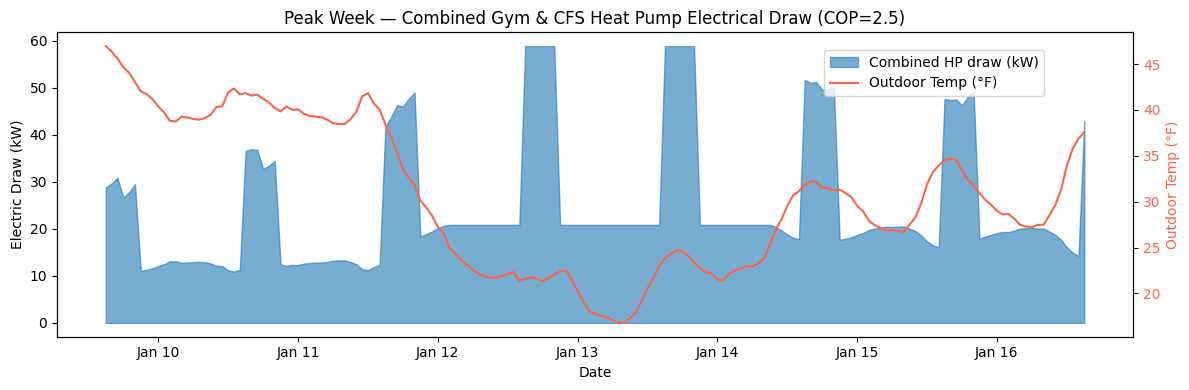

In [18]:
# ============================================================
# FURNACE HEAT PUMP ELECTRIFICATION ANALYSIS
# Add these cells after your existing scaling/pie-chart code
# ============================================================

# -------------------------------------------------------------
# CELL 1: Configuration
# -------------------------------------------------------------

# COP to use for cold-climate heat pump estimates
# 2.5 is conservative for PNW winter conditions; real COPs
# are higher at mild temps and lower near design minimum.
COP_LOW  = 2.0   # conservative bound (cold snaps near design min)
COP_MID  = 2.5   # central estimate used for reporting
COP_HIGH = 3.5   # mild-weather average

# Electricity carbon intensity (lbs CO2e/kWh) — use your
# local Puget Sound Energy grid factor or adjust as needed
ELEC_CI_LBS_PER_KWH = 0.18   # PSE 2024 reported grid average

BTU_PER_KWH = 3412.14

# Which heating units are furnace candidates for HP replacement
FURNACE_UNIT_IDS = ["unit_2", "unit_3"]   # Gym + CFS furnaces


# -------------------------------------------------------------
# CELL 2: Extract hourly thermal output for furnace units
# and build load profiles for ANALYSIS_YEAR
# -------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

YEAR = ANALYSIS_YEAR
mask_year = df.index.year == YEAR

fig, axes = plt.subplots(len(FURNACE_UNIT_IDS), 1,
                         figsize=(12, 4 * len(FURNACE_UNIT_IDS)),
                         sharex=True)
if len(FURNACE_UNIT_IDS) == 1:
    axes = [axes]

furnace_results = {}

for ax, uid in zip(axes, FURNACE_UNIT_IDS):
    params   = HEATING_EQUIPMENT[uid]
    col_in   = f"heat_btu_in_{uid}"

    # BTU input (fuel side) for this year
    btu_in   = df.loc[mask_year, col_in]

    # Thermal output (useful heat delivered)
    btu_out  = btu_in * params["efficiency"]

    # Equivalent electric consumption at each COP
    kwh_mid  = btu_out / BTU_PER_KWH / COP_MID
    kwh_low  = btu_out / BTU_PER_KWH / COP_LOW
    kwh_high = btu_out / BTU_PER_KWH / COP_HIGH

    # Monthly aggregates for bar chart
    monthly_kwh  = kwh_mid.resample("ME").sum()
    monthly_temp = df.loc[mask_year, "temp_f"].resample("ME").mean()

    furnace_results[uid] = {
        "name":           params["name"],
        "annual_btu_in":  float(btu_in.sum()),
        "annual_btu_out": float(btu_out.sum()),
        "annual_kwh_mid": float(kwh_mid.sum()),
        "annual_kwh_low": float(kwh_low.sum()),
        "annual_kwh_high":float(kwh_high.sum()),
        "peak_kw_mid":    float(kwh_mid.max()),   # hourly peak
        "monthly_kwh":    monthly_kwh,
        "monthly_temp":   monthly_temp,
    }

    # ── Plot: monthly electricity demand + avg temp overlay ──
    months = monthly_kwh.index
    bars   = ax.bar(months, monthly_kwh / 1000,   # MWh
                    width=20, color="#1f77b4", alpha=0.75,
                    label="Elec demand (COP=2.5)")

    ax2 = ax.twinx()
    ax2.plot(months, monthly_temp, color="tomato",
             marker="o", linewidth=1.5, label="Avg temp (°F)")
    ax2.set_ylabel("Avg Outdoor Temp (°F)", color="tomato")
    ax2.tick_params(axis="y", labelcolor="tomato")
    ax2.set_ylim(0, 80)

    ax.set_title(f"{params['name']} — Estimated Monthly Electricity if Replaced by CCHP (CY{YEAR})",
                 fontsize=11)
    ax.set_ylabel("Electricity Demand (MWh)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("furnace_hp_monthly_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: furnace_hp_monthly_profiles.png")


# -------------------------------------------------------------
# CELL 3: Summary table — annual electricity & peak demand
# -------------------------------------------------------------
print(f"\n{'='*65}")
print(f"  FURNACE → CCHP ELECTRIFICATION SUMMARY  (CY{YEAR})")
print(f"{'='*65}")
print(f"  COP assumptions: Low={COP_LOW}  Mid={COP_MID}  High={COP_HIGH}")
print(f"{'='*65}\n")

total_kwh_mid  = 0
total_kwh_low  = 0
total_kwh_high = 0
total_peak_kw  = 0

for uid, r in furnace_results.items():
    gal_equiv = r["annual_btu_in"] / BTU_PER_GALLON
    print(f"  {r['name']}")
    print(f"    Propane input (modeled)  : {gal_equiv:>8,.0f} gal/yr")
    print(f"    Thermal output           : {r['annual_btu_out']/1e6:>8,.1f} MMBtu/yr")
    print(f"    Est. electricity (COP {COP_LOW}) : {r['annual_kwh_low']/1000:>8,.1f} MWh/yr  [conservative]")
    print(f"    Est. electricity (COP {COP_MID}) : {r['annual_kwh_mid']/1000:>8,.1f} MWh/yr  [central estimate]")
    print(f"    Est. electricity (COP {COP_HIGH}) : {r['annual_kwh_high']/1000:>8,.1f} MWh/yr  [optimistic]")
    print(f"    Peak hourly draw (COP {COP_MID}): {r['peak_kw_mid']:>8,.1f} kW")
    print()

    total_kwh_mid  += r["annual_kwh_mid"]
    total_kwh_low  += r["annual_kwh_low"]
    total_kwh_high += r["annual_kwh_high"]
    total_peak_kw  += r["peak_kw_mid"]   # worst-case additive peak

print(f"  ── COMBINED TOTALS ──────────────────────────────────")
print(f"    Annual electricity (COP {COP_LOW}): {total_kwh_low/1000:>8,.1f} MWh/yr")
print(f"    Annual electricity (COP {COP_MID}): {total_kwh_mid/1000:>8,.1f} MWh/yr  ← report this")
print(f"    Annual electricity (COP {COP_HIGH}): {total_kwh_high/1000:>8,.1f} MWh/yr")
print(f"    Peak additive demand (COP {COP_MID}): {total_peak_kw:>6,.1f} kW")
print(f"\n  NOTE: Peak kW is additive worst-case. Coincident peak")
print(f"  will be lower since units serve different buildings.")


# -------------------------------------------------------------
# CELL 4: Hourly load duration curve — useful for sizing
# -------------------------------------------------------------
fig, axes = plt.subplots(1, len(FURNACE_UNIT_IDS),
                         figsize=(6 * len(FURNACE_UNIT_IDS), 4))
if len(FURNACE_UNIT_IDS) == 1:
    axes = [axes]

for ax, uid in zip(axes, FURNACE_UNIT_IDS):
    r      = furnace_results[uid]
    params = HEATING_EQUIPMENT[uid]
    col_in = f"heat_btu_in_{uid}"
    btu_in  = df.loc[mask_year, col_in]
    btu_out = btu_in * params["efficiency"]
    kw_mid  = (btu_out / BTU_PER_KWH / COP_MID)   # hourly kW

    sorted_kw = kw_mid.sort_values(ascending=False).values
    pct_hours = (100 * (1 + np.arange(len(sorted_kw))) / len(sorted_kw))

    ax.plot(pct_hours, sorted_kw, color="#1f77b4", linewidth=1.5)
    ax.axhline(kw_mid.mean(), color="tomato", linestyle="--",
               linewidth=1, label=f"Mean = {kw_mid.mean():.1f} kW")
    ax.set_xlabel("% of Hours Exceeded")
    ax.set_ylabel("Electric Draw (kW)")
    ax.set_title(f"{r['name']}\nLoad Duration Curve (CY{YEAR}, COP={COP_MID})")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("furnace_hp_load_duration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: furnace_hp_load_duration.png")

# CELL 5 fix — use combined_kw directly for temp too, don't re-index into df

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.fill_between(combined_kw[week_mask].index,
                 combined_kw[week_mask].values,
                 alpha=0.6, color="#1f77b4", label="Combined HP draw (kW)")
ax1.set_ylabel("Electric Draw (kW)")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

# Pull temp from the already-filtered year slice, not full df
temp_year = df.loc[mask_year, "temp_f"]
ax2.plot(temp_year[week_mask].index,
         temp_year[week_mask].values,
         color="tomato", linewidth=1.5, label="Outdoor Temp (°F)")
ax2.set_ylabel("Outdoor Temp (°F)", color="tomato")
ax2.tick_params(axis="y", labelcolor="tomato")

ax1.set_title(f"Peak Week — Combined Gym & CFS Heat Pump Electrical Draw (COP={COP_MID})")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig("furnace_hp_peak_week.png", dpi=150, bbox_inches="tight")
plt.show()



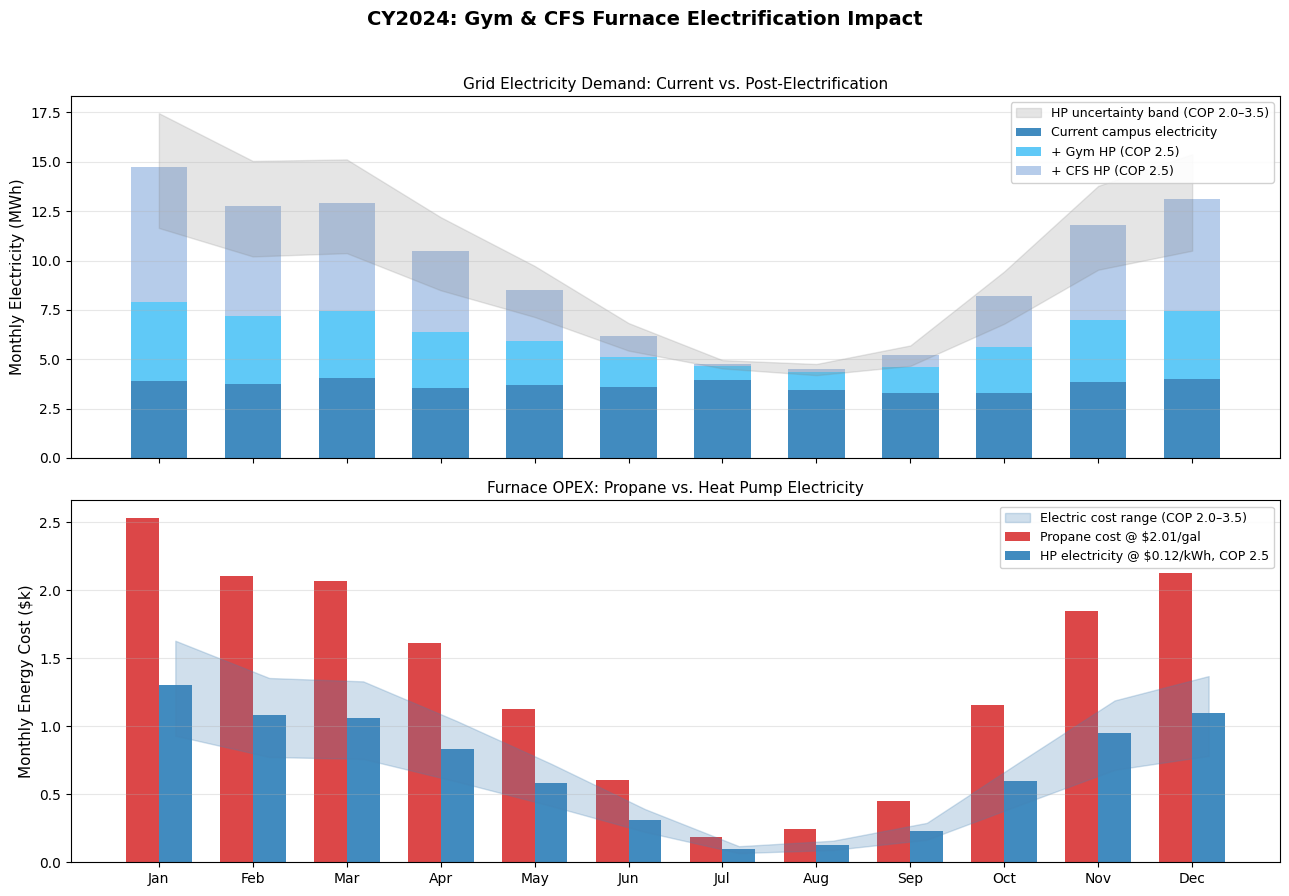

Saved: furnace_electrification_opex.png

  FURNACE ELECTRIFICATION SUMMARY  (CY2024)
  Current campus electricity : 44 MWh/yr
  HP addition (COP 2.5)     : 69 MWh/yr (+155%)
  Post-electrification total : 113 MWh/yr
  Annual propane cost        : $16,063/yr
  Annual HP elec cost        : $8,266/yr
  Estimated annual savings   : $7,797/yr


In [22]:
# ============================================================
# FURNACE ELECTRIFICATION — Stacked Electricity + OPEX Plot
# Add this cell after your existing scaling/furnace analysis code
# Requires: df (hourly temps, ANALYSIS_YEAR filtered), elec CSV
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Rate assumptions (update as needed) ─────────────────────
ELEC_RATE   = 0.12    # $/kWh — PSE Schedule 25 energy charge only
PROP_PRICE  = 2.01    # $/gal — WA commercial propane average 2024
# Note: Schedule 25 also carries a demand charge (~$13/kW Oct-Mar,
# ~$9/kW Apr-Sep) not captured here — true electricity cost will
# be higher. Energy charge used for like-for-like comparison.

# ── Load & resample electricity data ────────────────────────
elec_raw = pd.read_csv(HOURLY_TEMPS_FILE.replace(
    "ERA5 Hourly Temperatures 2015-2026.csv",
    "15-minute Electricity 2023-2025.csv"
), index_col=0, parse_dates=True)

# Strip timezone for clean resampling
elec_raw.index = elec_raw.index.tz_localize(None) \
    if elec_raw.index.tzinfo is None \
    else elec_raw.index.tz_convert(None)

elec_year    = elec_raw[elec_raw.index.year == ANALYSIS_YEAR]
elec_monthly = elec_year["USAGE (kWh)"].resample("MS").sum()

# ── Furnace units to electrify ───────────────────────────────
FURNACE_UNIT_IDS = ["unit_2", "unit_3"]   # Gym + CFS furnaces

# ── Build monthly furnace kWh & gallon profiles ──────────────
# Uses df already filtered to ANALYSIS_YEAR from your main notebook
df_year = df[df.index.year == ANALYSIS_YEAR].copy()
df_year.index = df_year.index.tz_localize(None) \
    if df_year.index.tzinfo is None \
    else df_year.index.tz_convert(None)

furnace = {}
for uid in FURNACE_UNIT_IDS:
    p   = HEATING_EQUIPMENT[uid]
    bp  = p.get("balance_point_f", BALANCE_POINT_F)
    dc  = compute_duty_cycle(df_year["temp_f"], balance_point=bp, design_min=DESIGN_MIN_F)

    hour = df_year.index.hour
    dow  = df_year.index.dayofweek
    occ  = (pd.Series(dow, index=df_year.index).isin(p["occupied_days"]) &
            (hour >= p["occupied_start_hr"]) & (hour < p["occupied_end_hr"]))

    sb    = p.get("setback_temp_f", 0)
    dc_sb = (compute_duty_cycle(df_year["temp_f"], balance_point=sb, design_min=DESIGN_MIN_F)
             if sb > DESIGN_MIN_F else pd.Series(0., index=df_year.index))
    dc_eff = dc.where(occ, dc_sb)

    btu_in  = p["rated_input_btu_hr"] * dc_eff
    btu_out = btu_in * p["efficiency"]

    furnace[uid] = {
        "name":     p["name"],
        "kwh_mid":  (btu_out / BTU_PER_KWH / COP_MID ).resample("MS").sum(),
        "kwh_low":  (btu_out / BTU_PER_KWH / COP_LOW ).resample("MS").sum(),
        "kwh_high": (btu_out / BTU_PER_KWH / COP_HIGH).resample("MS").sum(),
        "gal":      (btu_in  / BTU_PER_GALLON         ).resample("MS").sum(),
    }

# Align all series to electricity monthly index
idx = elec_monthly.index
for uid in FURNACE_UNIT_IDS:
    for k in furnace[uid]:
        if isinstance(furnace[uid][k], pd.Series):
            furnace[uid][k] = furnace[uid][k].reindex(idx, fill_value=0)

gym = furnace["unit_2"]
cfs = furnace["unit_3"]

add_mid  = gym["kwh_mid"]  + cfs["kwh_mid"]
add_low  = gym["kwh_low"]  + cfs["kwh_low"]
add_high = gym["kwh_high"] + cfs["kwh_high"]

prop_cost     = (gym["gal"] + cfs["gal"]) * PROP_PRICE
elec_cost_mid  = add_mid  * ELEC_RATE
elec_cost_low  = add_low  * ELEC_RATE
elec_cost_high = add_high * ELEC_RATE

# ── Annual summary values ────────────────────────────────────
ann_curr_mwh  = elec_monthly.sum() / 1000
ann_add_mwh   = add_mid.sum() / 1000
ann_prop_cost = prop_cost.sum()
ann_elec_cost = elec_cost_mid.sum()
ann_savings   = ann_prop_cost - ann_elec_cost
pct_increase  = 100 * ann_add_mwh / ann_curr_mwh

# ── Plot ─────────────────────────────────────────────────────
month_labels = [m.strftime("%b") for m in idx]
x = np.arange(len(idx))
w = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle(f"CY{ANALYSIS_YEAR}: Gym & CFS Furnace Electrification Impact",
             fontsize=14, fontweight="bold", y=0.99)

# ── Panel 1: Stacked monthly electricity demand ──────────────
ax1.bar(x, elec_monthly / 1000, width=0.6,
        color="#1f77b4", alpha=0.85, label="Current campus electricity")
ax1.bar(x, gym["kwh_mid"] / 1000, width=0.6,
        bottom=elec_monthly / 1000,
        color="#4fc3f7", alpha=0.9, label=f"+ Gym HP (COP {COP_MID})")
ax1.bar(x, cfs["kwh_mid"] / 1000, width=0.6,
        bottom=(elec_monthly + gym["kwh_mid"]) / 1000,
        color="#aec7e8", alpha=0.9, label=f"+ CFS HP (COP {COP_MID})")
ax1.fill_between(x,
                 (elec_monthly / 1000 + add_low  / 1000).values,
                 (elec_monthly / 1000 + add_high / 1000).values,
                 alpha=0.2, color="gray",
                 label=f"HP uncertainty band (COP {COP_LOW}–{COP_HIGH})")

ax1.set_ylabel("Monthly Electricity (MWh)", fontsize=11)
ax1.set_title("Grid Electricity Demand: Current vs. Post-Electrification", fontsize=11, pad=5)
ax1.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax1.grid(axis="y", alpha=0.3)
#ax1.text(0.02, 0.95,
         #f"Current annual: {ann_curr_mwh:.0f} MWh/yr\n"
         #f"HP addition (COP {COP_MID}): +{ann_add_mwh:.0f} MWh/yr "
         #f"({pct_increase:.0f}% increase)\n"
         #f"Total post-electrification: {ann_curr_mwh + ann_add_mwh:.0f} MWh/yr",
         #transform=ax1.transAxes, fontsize=9, va="top",
         #bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.85))

# ── Panel 2: Monthly OPEX — propane vs. electricity ──────────
ax2.bar(x - w/2, prop_cost / 1000, width=w,
        color="#d62728", alpha=0.85,
        label=f"Propane cost @ ${PROP_PRICE}/gal")
ax2.bar(x + w/2, elec_cost_mid / 1000, width=w,
        color="#1f77b4", alpha=0.85,
        label=f"HP electricity @ ${ELEC_RATE}/kWh, COP {COP_MID}")
ax2.fill_between(x + w/2,
                 elec_cost_low / 1000, elec_cost_high / 1000,
                 alpha=0.25, color="steelblue",
                 label=f"Electric cost range (COP {COP_LOW}–{COP_HIGH})")

ax2.set_ylabel("Monthly Energy Cost ($k)", fontsize=11)
ax2.set_title("Furnace OPEX: Propane vs. Heat Pump Electricity", fontsize=11, pad=5)
ax2.set_xticks(x)
ax2.set_xticklabels(month_labels, fontsize=10)
ax2.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax2.grid(axis="y", alpha=0.3)
#ax2.text(0.02, 0.95,
         #f"Annual propane cost (furnaces): ${ann_prop_cost:,.0f}/yr\n"
         #f"Annual HP electricity cost (COP {COP_MID}): ${ann_elec_cost:,.0f}/yr\n"
         #f"Estimated annual savings: ${ann_savings:,.0f}/yr\n"
         #f"Note: excludes PSE Schedule 25 demand charge (~$13/kW Oct–Mar)",
         #transform=ax2.transAxes, fontsize=9, va="top",
         #bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.85))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("furnace_electrification_opex.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: furnace_electrification_opex.png")

# ── Console summary ──────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  FURNACE ELECTRIFICATION SUMMARY  (CY{ANALYSIS_YEAR})")
print(f"{'='*55}")
print(f"  Current campus electricity : {ann_curr_mwh:.0f} MWh/yr")
print(f"  HP addition (COP {COP_MID})     : {ann_add_mwh:.0f} MWh/yr (+{pct_increase:.0f}%)")
print(f"  Post-electrification total : {ann_curr_mwh + ann_add_mwh:.0f} MWh/yr")
print(f"  Annual propane cost        : ${ann_prop_cost:,.0f}/yr")
print(f"  Annual HP elec cost        : ${ann_elec_cost:,.0f}/yr")
print(f"  Estimated annual savings   : ${ann_savings:,.0f}/yr")
